# IMM Transition Matrix Tuning

The key idea is simple: if a typical maneuver lasts `T` seconds, the IMM model-probability Markov chain should mix quickly enough to react during the maneuver, but not so quickly that model probabilities become dominated by measurement noise.

A useful target is therefore:

$$
\tau_\varepsilon \lesssim T/10
$$

where $\tau_\varepsilon$ is the mixing time for a total-variation tolerance $\varepsilon$.

## Markov Transition Matrix

For an IMM with `n` models, define the row-stochastic transition matrix

$$
P_{ij}=\Pr(m_{k+1}=j\mid m_k=i), \qquad \sum_j P_{ij}=1.
$$

Large diagonal entries mean each model is persistent. Larger off-diagonal entries make switching easier. In many IMM implementations `P[i, j]` is read as the probability of switching from model `i` to model `j` in one filter update.

## Mixing Time And Spectral Gap

Let $\pi$ be the stationary distribution of the Markov chain, i.e.

$$
\pi P = \pi.
$$

The total-variation distance after `k` discrete IMM updates, starting from an initial model distribution $\mu_0$, is

$$
d_\mathrm{TV}(\mu_0P^k, \pi) = \frac{1}{2}\sum_i |(\mu_0P^k)_i-\pi_i|.
$$

The $\varepsilon$-mixing time is the smallest `k` such that this distance is below $\varepsilon$ for every possible initial model:

$$
\tau_\varepsilon = \min\left\{k: \max_{\mu_0} d_\mathrm{TV}(\mu_0P^k, \pi) \le \varepsilon\right\}.
$$

The spectral gap is computed here as

$$
\beta = 1 - \max_{i\ge 2}|\lambda_i(P)|,
$$

where $\lambda_1=1$ is the dominant eigenvalue. A larger spectral gap generally means faster mixing.

A common finite-state Markov-chain bound is

$$
\tau_{\varepsilon}
\lesssim
\frac{\log\left(1/(\varepsilon\pi_{\min})\right)}{\beta}
$$

with $\pi_{\min}=\min_{i}\pi_i$. This bound is conservative, especially for non-reversible chains, but it is useful as a tuning guideline.

If the desired mixing time is `T / 10`, and the filter update period is `dt`, then the target number of IMM updates is

$$
k_\mathrm{target}=\frac{T/10}{dt}.
$$

A sufficient spectral-gap guideline is therefore

$$
\beta \gtrsim
\frac{\log\!\left(\frac{1}{\varepsilon \pi_{\min}}\right)}
     {k_{\mathrm{target}}}.
$$

Because the bound can be conservative, the notebook also computes the exact finite-state mixing time numerically.

In [17]:
import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(precision=4, suppress=True)
plt.rcParams.update({
    "figure.figsize": (9, 4),
    "axes.grid": True,
    "lines.linewidth": 2,
})

## User Inputs

Edit this cell with the IMM transition matrix and timing assumptions. The default example uses three persistent models with moderate switching probability.

In [18]:
# Transition matrix P[i, j] = probability of moving from model i to model j.
# Replace model_names and P with the IMM models used in your tracker.
model_names = ["CCV", "CCM-A", "CCM-B"]

P = np.array([
    [0.50, 0.25, 0.25],
    [0.25, 0.50, 0.25],
    [0.25, 0.25, 0.50],
], dtype=float)

# Filter update period [s]. Set this to the target-tracking IMM update time.
dt = 0.015

# Typical maneuver duration [s]. The MATLAB note used T = 5 s.
T = 5.0

# Total-variation tolerance for mixing-time checks.
eps = 0.1

# Optional: initial model probability for the convergence plot.
mu0 = np.array([1.0, 0.0, 0.0])

In [19]:
def validate_transition_matrix(P, atol=1e-10):
    P = np.asarray(P, dtype=float)
    if P.ndim != 2 or P.shape[0] != P.shape[1]:
        raise ValueError("P must be a square matrix.")
    if np.any(P < -atol):
        raise ValueError("P must contain non-negative probabilities.")
    row_sums = P.sum(axis=1)
    if not np.allclose(row_sums, 1.0, atol=atol):
        raise ValueError(f"Rows of P must sum to 1. Row sums are {row_sums}.")
    return P


def stationary_distribution(P):
    # For row-stochastic P, the stationary distribution is the left eigenvector for eigenvalue 1.
    eigvals, eigvecs = np.linalg.eig(P.T)
    idx = np.argmin(np.abs(eigvals - 1.0))
    pi = np.real(eigvecs[:, idx])
    if np.sum(pi) < 0:
        pi = -pi
    pi = pi / np.sum(pi)
    pi = np.maximum(pi, 0.0)
    pi = pi / np.sum(pi)
    return pi


def spectral_gap(P):
    eigvals = np.linalg.eigvals(P)
    sorted_abs = np.sort(np.abs(eigvals))[::-1]
    lambda2_abs = sorted_abs[1]
    beta = 1.0 - lambda2_abs
    return beta, eigvals


def total_variation(mu, pi):
    return 0.5 * np.sum(np.abs(mu - pi))


def exact_mixing_time(P, pi, eps=0.1, max_steps=100_000):
    n = P.shape[0]
    distributions = np.eye(n)
    distances = []

    for k in range(max_steps + 1):
        worst_distance = max(total_variation(distributions[i], pi) for i in range(n))
        distances.append(worst_distance)
        if worst_distance <= eps:
            return k, np.array(distances)
        distributions = distributions @ P

    return None, np.array(distances)


def simulate_model_probabilities(P, mu0, steps):
    probs = np.empty((steps + 1, P.shape[0]))
    probs[0] = mu0
    for k in range(steps):
        probs[k + 1] = probs[k] @ P
    return probs

## Compute Tuning Metrics

In [20]:
P = validate_transition_matrix(P)
n_models = P.shape[0]

if len(model_names) != n_models:
    model_names = [f"model_{i}" for i in range(n_models)]

pi = stationary_distribution(P)
pi_min = np.min(pi)
beta, eigvals = spectral_gap(P)

target_mixing_seconds = T / 10.0
target_mixing_steps = target_mixing_seconds / dt
beta_required = np.log(1.0 / (eps * pi_min)) / target_mixing_steps

mixing_steps, tv_distances = exact_mixing_time(P, pi, eps=eps)
mixing_seconds = None if mixing_steps is None else mixing_steps * dt

summary = [
    ("models", n_models),
    ("dt [s]", dt),
    ("maneuver duration T [s]", T),
    ("target mixing time T/10 [s]", target_mixing_seconds),
    ("epsilon", eps),
    ("pi_min", pi_min),
    ("spectral gap beta", beta),
    ("required beta guideline", beta_required),
    ("exact mixing time [steps]", mixing_steps),
    ("exact mixing time [s]", mixing_seconds),
]

summary

[('models', 3),
 ('dt [s]', 0.015),
 ('maneuver duration T [s]', 5.0),
 ('target mixing time T/10 [s]', 0.5),
 ('epsilon', 0.1),
 ('pi_min', np.float64(0.3333333333333332)),
 ('spectral gap beta', np.float64(0.75)),
 ('required beta guideline', np.float64(0.10203592144986467)),
 ('exact mixing time [steps]', 2),
 ('exact mixing time [s]', 0.03)]

In [21]:
print("Transition matrix P:")
header = "          " + "".join(f"{name:>10s}" for name in model_names)
print(header)
for name, row in zip(model_names, P):
    print(f"{name:>10s}" + "".join(f"{value:10.4f}" for value in row))

print("\nStationary distribution pi:")
for name, value in zip(model_names, pi):
    print(f"  {name}: {value:.6f}")

print("\nEigenvalues of P:")
for val in eigvals:
    print(f"  {val.real:+.6f}{val.imag:+.6f}j")

print("\nTuning check:")
if beta >= beta_required:
    print(f"PASS: beta = {beta:.4f} >= required guideline {beta_required:.4f}")
else:
    print(f"WARNING: beta = {beta:.4f} < required guideline {beta_required:.4f}")

if mixing_seconds is not None and mixing_seconds <= target_mixing_seconds:
    print(f"PASS: exact mixing time = {mixing_seconds:.3f} s <= target {target_mixing_seconds:.3f} s")
elif mixing_seconds is not None:
    print(f"WARNING: exact mixing time = {mixing_seconds:.3f} s > target {target_mixing_seconds:.3f} s")
else:
    print("WARNING: exact mixing time was not reached within max_steps.")

Transition matrix P:
                 CCV     CCM-A     CCM-B
       CCV    0.5000    0.2500    0.2500
     CCM-A    0.2500    0.5000    0.2500
     CCM-B    0.2500    0.2500    0.5000

Stationary distribution pi:
  CCV: 0.333333
  CCM-A: 0.333333
  CCM-B: 0.333333

Eigenvalues of P:
  +0.250000+0.000000j
  +1.000000+0.000000j
  +0.250000+0.000000j

Tuning check:
PASS: beta = 0.7500 >= required guideline 0.1020
PASS: exact mixing time = 0.030 s <= target 0.500 s


## Visualize Mixing

The first plot shows the worst-case total-variation distance to stationarity over all one-hot initial model distributions. The second plot shows how a chosen initial distribution `mu0` evolves under the transition matrix.

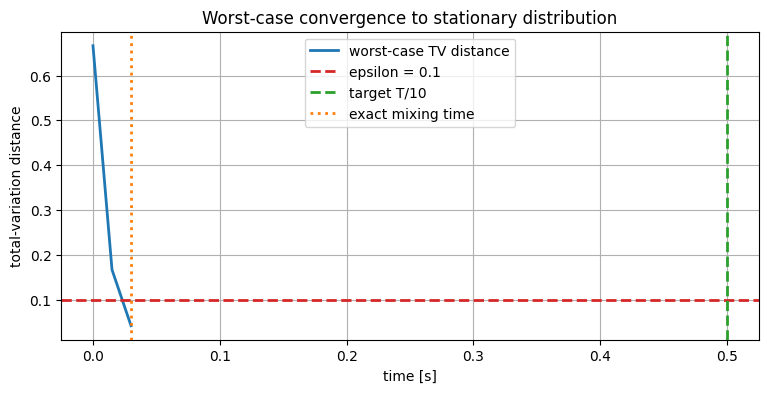

In [22]:
time_tv = np.arange(len(tv_distances)) * dt

fig, ax = plt.subplots()
ax.plot(time_tv, tv_distances, label="worst-case TV distance")
ax.axhline(eps, color="tab:red", linestyle="--", label=f"epsilon = {eps}")
ax.axvline(target_mixing_seconds, color="tab:green", linestyle="--", label="target T/10")
if mixing_seconds is not None:
    ax.axvline(mixing_seconds, color="tab:orange", linestyle=":", label="exact mixing time")
ax.set_xlabel("time [s]")
ax.set_ylabel("total-variation distance")
ax.set_title("Worst-case convergence to stationary distribution")
ax.legend()
plt.show()

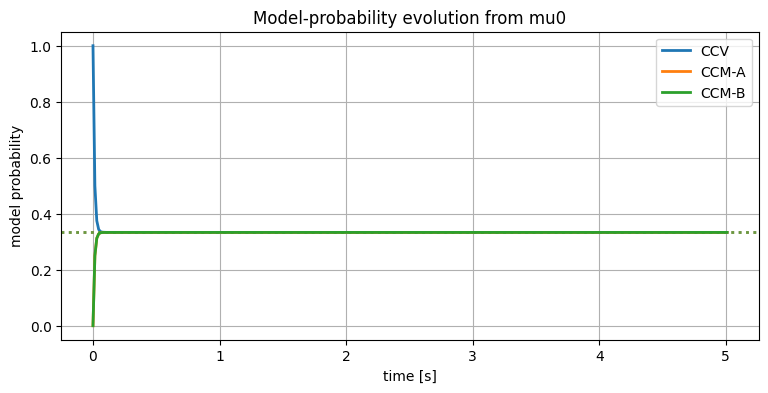

In [23]:
steps_to_plot = int(np.ceil(max(T, target_mixing_seconds) / dt))
probs = simulate_model_probabilities(P, mu0 / np.sum(mu0), steps_to_plot)
time_probs = np.arange(steps_to_plot + 1) * dt

fig, ax = plt.subplots()
for i, name in enumerate(model_names):
    ax.plot(time_probs, probs[:, i], label=name)
    ax.axhline(pi[i], color=ax.lines[-1].get_color(), linestyle=":", alpha=0.6)

ax.set_xlabel("time [s]")
ax.set_ylabel("model probability")
ax.set_title("Model-probability evolution from mu0")
ax.legend()
plt.show()

## Optional Interactive Input Box

If `ipywidgets` is installed, this cell gives a compact input box for experimenting with a common symmetric transition matrix:

$$
P_{ii}=p_\mathrm{stay}, \qquad P_{ij}=\frac{1-p_\mathrm{stay}}{n-1}, \quad i\ne j.
$$

Decrease `p_stay` for faster model switching. Increase it for more persistent model probabilities.

In [24]:
try:
    import ipywidgets as widgets
    from IPython.display import display

    n_widget = widgets.IntSlider(value=n_models, min=2, max=8, step=1, description="models")
    p_widget = widgets.FloatSlider(value=float(np.mean(np.diag(P))), min=0.0, max=0.999, step=0.001, description="p_stay")
    dt_widget = widgets.FloatText(value=dt, description="dt [s]")
    T_widget = widgets.FloatText(value=T, description="T [s]")
    eps_widget = widgets.FloatText(value=eps, description="eps")

    def evaluate_symmetric_matrix(n, p_stay, dt, T, eps):
        if n <= 1:
            raise ValueError("n must be greater than 1")
        P_sym = np.full((n, n), (1.0 - p_stay) / (n - 1))
        np.fill_diagonal(P_sym, p_stay)
        pi_sym = stationary_distribution(P_sym)
        beta_sym, _ = spectral_gap(P_sym)
        target_steps = (T / 2.0) / dt
        beta_req_sym = np.log(1.0 / (eps * np.min(pi_sym))) / target_steps
        mix_steps_sym, _ = exact_mixing_time(P_sym, pi_sym, eps=eps)
        mix_sec_sym = None if mix_steps_sym is None else mix_steps_sym * dt
        print(f"beta = {beta_sym:.4f}")
        print(f"required beta guideline = {beta_req_sym:.4f}")
        print(f"exact mixing time = {mix_sec_sym} s")
        print("P =")
        print(P_sym)

    interactive_box = widgets.interactive(
        evaluate_symmetric_matrix,
        n=n_widget,
        p_stay=p_widget,
        dt=dt_widget,
        T=T_widget,
        eps=eps_widget,
    )
    display(interactive_box)
except ImportError:
    print("ipywidgets is not installed. Edit the User Inputs cell instead.")

interactive(children=(IntSlider(value=3, description='models', max=8, min=2), FloatSlider(value=0.5, descripti…

## IMM Model-Probability Update

At each correction step, the IMM updates the probability of each model by combining two pieces of information: the Markov transition matrix and the measurement likelihood of each model.

For model `i`, the innovation covariance is

$$
S_i = C_i P_i C_i^T + R_i,
$$

where $C_i$ is the measurement matrix, $P_i$ is the model covariance, and $R_i$ is the measurement-noise covariance. Given the measurement residual $z_i$, the Gaussian residual likelihood is

$$
L_i = \frac{\exp\left(-\frac{1}{2} z_i^T S_i^{-1} z_i\right)}{(2\pi)^{M/2}\sqrt{\det(S_i)}}.
$$

The likelihood $L_i$ has a physical interpretation as the compatibility between the current measurement residual and model `i`. A high likelihood means that the residual is plausible given the model covariance and measurement noise; a low likelihood means that the residual is unexpectedly large for that model. However, $L_i$ is a probability density, not the probability that model `i` is correct. Its absolute value depends on the measurement units and dimension, so the most meaningful quantity is usually the relative likelihood between models.

Before applying the measurement likelihoods, the previous model probabilities $\mu$ are propagated through the Markov transition matrix:

$$
\bar{c} = P^T \mu. 
$$

The predicted probabilities $\bar{c}$ are then reweighted by the likelihoods and normalized:

$$
\mu_i^+ = \frac{\bar{c}_i L_i}{\sum_j \bar{c}_j L_j}.
$$

This is the key Bayesian update in the IMM: the Markov chain predicts which model should be active, while the current measurement increases the probability of models whose residuals are more consistent with their predicted uncertainty. For tuning, this means `P` controls how much probability can move between models before the measurement correction, and the likelihoods control how strongly the current data can override that prior.


## Similar Models And Stationary Convergence

If all IMM models give similar likelihoods or very similar state predictions, the measurements do not provide a strong reason to prefer one model over another. In that case, the model-probability update is dominated by the Markov transition matrix `P` rather than by the data.

Repeated application of `P` quickly drives the model probabilities toward the stationary distribution $\pi$ of the Markov chain:

$$
\mu_k \approx \mu_0 P^k \rightarrow \pi.
$$

Therefore, when the models are almost indistinguishable, the IMM will rapidly converge to the stationary solution of the Markov chain. This is useful as a sanity check: if the logs show nearly constant model likelihoods and the probabilities settle near $\pi$, that behavior is expected and is mainly controlled by the mixing time of `P`.


## Soften Likelihoods Instead Of Fast Mixing

Do not use aggressive mixing to smooth noise. Large off-diagonal values in `P` force the model states to collapse toward one another, which makes the residuals and likelihoods look similar across models. Once that happens, the probabilities stop reflecting model differences and drift toward the stationary distribution. In practice, fast mixing removes discrimination instead of improving it.

A better IMM-specific knob is likelihood tempering:

$$
\mu_i^+ \propto \bar{c}_i L_i^{\alpha}
$$

with $\alpha \in [0.3, 0.7]$. This softens residual spikes without forcing all models into the same mixed state. The Markov chain still provides the prior over models, but the measurement update becomes less dominated by a single outlier likelihood.

Use this when one model briefly produces a very small likelihood and you want to reduce overreaction while preserving model separation.

## Practical Interpretation

- If the exact mixing time is much larger than `T / 10`, model probabilities may remain almost constant during a maneuver. Reduce diagonal probabilities or increase off-diagonal switching probabilities.
- If the exact mixing time is much smaller than `T / 10`, the IMM can react quickly, but may become sensitive to noise. Increase diagonal probabilities if model probabilities are too jumpy in logs.
- The spectral-gap inequality is a conservative guideline. The exact finite-state mixing time computed above is usually the more direct diagnostic for a specific transition matrix.
- After choosing `P`, validate it on tracking logs by plotting model probabilities, innovation consistency, and state-estimation errors during known maneuvers.